# Part 1

## Introduction

Exponentials are intimately related to products and multiplication.
The most obvious relationship is that the multiplication of exponentials results in the addition of their exponents.
But more importantly, the exponential function describes fractional _growth_, repeatedly growing something in a multiplicative way.
To understand this, I highly recommend reading [this](https://betterexplained.com/articles/an-intuitive-guide-to-exponential-functions-e/) and [this](https://betterexplained.com/articles/demystifying-the-natural-logarithm-ln/) article on [betterexplained.com](https://betterexplained.com/), before getting started with this article.

The connection that I explore in this post is that _taking any function to a large power (“growing” them locally) lets them converge locally to exponentials_. It turns out that this convergence to exponentials is extremely helpful to understand the _generalized_ central limit theorem that not only explains why many sums of random variables converge to a normal distributions, but also why some others converge to so-called alpha-stable distributions instead, in particular those with certain asymptotic power-law behaviour.

## A simple identity that explains a lot

Exponentials are related to fractional growth through a core identity that we will use _massively_ in this and the following posts and that is therefore crucial to understand:

$$
e^{x} = \lim_{n \rightarrow \infty} (1 + \frac{x}{n})^n \qquad \text{(1)}
$$

In words, this identity states that, as we take a specific _linear_ function to the power of $n$, it converges to an exponential in the limit. Much of this first post is about showing that we can locally apply this identity to basically _any_ function, which leads us to the surprising conclusion that _any_ function locally converges to different forms of exponentials if we take it to a high power.

One way to see that the right hand side of the equation (1) indeed converges to an exponential is to expand it with the [binomial theorem](https://en.wikipedia.org/wiki/Binomial_theorem#Statement):

$$
(1+\frac{x}{n})^n = 1 + x + \frac{n(n-1)}{n^2}\frac{x^2}{2!} + \frac{n(n-1)(n-2)}{n^3}\frac{x^3}{3!} + \cdots + \frac{n}{n^{n-1}} x^{n-1} + (\frac{x}{n})^n
\qquad \text(2)
$$

In the limit $n \rightarrow \infty$, the _low power_ terms in this equation converge to the [Taylor series](https://en.wikipedia.org/wiki/Taylor_series#Exponential_function) (around zero) of the exponential function:

$$
e^x = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \cdots \qquad (3)
$$

The low power terms in equations (2) and (3) describe the behaviour of the converging, and the exponential functions for small $x$, whereas high power terms describe their behaviour for large values of $|x|$. This means that we can expect the convergence to be most accurate in the region around $x=0$, within a zone that scales with $n$. Let's get a visual impression of this convergence by plotting the right hand side of equation (1) for a range of increasing $n$. I use the excellent `sympy` package throughout this post for illustrations.

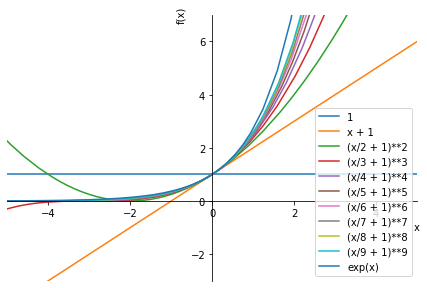

In [6]:
import sympy as sp
x, n, y, alpha = sp.symbols("x, n, y, \alpha")
exp = (1 + x/n)**n
sp.plot(*[exp.subs(n, i) for i in range(10)], sp.exp(x), xlim=(-5, 5), ylim=(-3, 7), legend=True);

It's fascinating how this expression evolves from a constant ($n=0$) over a line ($n=1$) to something that more closely resembles an exponential. Basically, in the process, we are adding higher and higher powers of $x$ and thus gradually build up the exponential function that has them all.

An interesting, and enlightening aspect of this convergence is the position of the (single) zero crossings of the nth-function that is simple to compute:

$$
(1 + \frac{x_0}{n})^n = 0 \Rightarrow x_0 = -n \qquad (4)
$$

The zero crossing is at position $-n$ and thus moves further and further out to the left as $n$ grows and as the expression accurately resembles the positiv-definite exponential in a larger and larger zone.

## Rescaling the coordinate system for a better look

Imagine now that we change the term within the brackets to something that occurs more often in the wild:

$$
\lim_{n \rightarrow \infty} (1 + x)^n \qquad (5)
$$

This is a simple polynomial, but we can transform this with a simple trick into something more similar to our core identity in equation (1) to look at it with a different eye:

$$
\lim_{n \rightarrow \infty} (1 + \frac{nx}{n})^n \qquad (6)
$$

Another artifice allows exploring this limit and also understand how convergence happens: Instead of $x$, we look at equation (6) in a _zoomed_ coordinate system $y=nx$. The above expression will then converge to $e^{y} = e^{nx}$. In this new coordinate system, an $n$ times _smaller_ value of $x$ leads to the same value than in the old. Therefore in the zoomed coordinates $y$, equation (6) looks exactly like the exponential in equation (1). And in the original, unzoomed coordinates, it looks like a version of equation (1) that gets gradually zoomed as $n$ grows. With this in mind, let's have a look at the plot of equation (6) for a range of $n$.

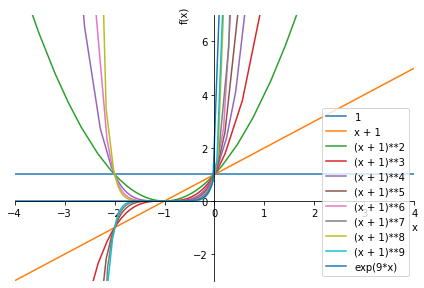

In [7]:
exp = (1 + n*x/n)**n
sp.plot(*[exp.subs(n, i) for i in range(10)], sp.exp(9*x), xlim=(-4, 4), ylim=(-3, 7), legend=True);

Admittedly, this looks a bit confusing. Keep in mind, that we are showing the _unzoomed_ coordinate system above, so we expect to see the equation converging to exponentials that are more and more squashed around $x=0$ as $n$ grows. And in fact, if you look at the above plot, only at the part greater than $x=-1$, you can indeed see them (we have plotted a true exponential for reference).

If you think this was heavy gymnastics, consider this: How about looking at the simple equation $x^n$ in the same way? Can we see it as an exponential in the limit of large $n$ in some coordinate system? Let's try the same trick as before:

$$
\lim_{n \rightarrow \infty} x^n = \lim_{n \rightarrow \infty} (1 + \frac{n(x-1)}{n})^n \qquad (7)
$$

To look at this limit, we now introduce the _shifted and zoomed_ coordinate $y=n(x-1)$. In this coordinate system, equation (7) converges to $e^y=e^{n(x-1)}$. In fact, we don't need a new plot anymore for this, because it is simply the same as before but shifted along the $x$ axis by $1$ to the left. If you simply look at the plot above, you can see the shifted $x^n$ function. Following our line of thought, this function should converge to a squashed exponential around $x=0$ in the plot, and around $x=1$ in equation (7).

One way to see that $x^n$ and $e^y$ resemble each other in the limit of large $n$, is to compare their derivatives at point $x=1$. The first derivative of $x^n$ evaluated at $x=1$ is simply $n$, and the derivative of $e^{n(x-1)}$, evaluated at point $1$, is similarly $n$. However, the second and higher derivatives of these two functions are _not_ the same. The exponential derivatives are $n^k$, where $k$ is the number of the derivative, whereas the power derivatives are $n(n-1)\cdots(n-k)$ - they decay. But _once we go to the limit of $n \rightarrow \infty$_, both will actually look the same, the decay of the power derivatives makes less and less of a _relative_ difference then, and $x^n$ starts to look like $e^{n(x-1)}$ around $x=1$. The convergence of $\frac{n(n-1)\cdots(n-k)}{n^k} \rightarrow 1$ for $n \rightarrow \infty$ and for $k \ll n$ is actually exactly the same argument as the one we used before when looking at the binomial theorem in equation (2) directly.

[Optional example: Concretely, think about $f(x) = x^3$, with low $n$, far from convergence. The values of its first three derivatives at $x=1$ are $f'(x=1)=3, f''(x=1)=6, f'''(x=1)=6$, compared to the first three derivatives of $g(x) = e^{nx}$ at $x=0$ that are $g'(x=0)=3, g''(x=0)=9, g'''(x=0)=27$, a relative difference of 50% in the second and 450% in the third. And now $f(x) = x^20$, with higher $n$, closer to convergence. The values of its first three derivatives at $x=1$ are $f'(x=1)=20, f''(x=1)=380, f'''(x=1)=6840$, compared to the first three derivatives of $g(x) = e^{nx}$ at $x=0$ that are $g'(x=0)=20, g''(x=0)=400, g'''(x=0)=8000$, a much smaller _relative_ difference of 5% in the second and 17% in the third derivative.]

## Nonlinearities 

With these basic insights in our backpack, let's consider a _non-linear_ variant in $x$ of our core identity to explore what happens to an expression like $1-x^2$ when taking it to a large power:

$$
\lim_{n \rightarrow \infty}(1 - \frac{nx^2}{n})^n \qquad (8)
$$

Note that we can't instantly introduce the same zoomed coordinate system as before here, because we introduced a non-linearity in $x$, but not in $n$. But we can introduce a different one, $y=\sqrt{n}x$, now, and in this coordinate system, equation (8) converges to $e^{y} = e^{-nx^2}$. A plot is again insightful to gain confidence in this:

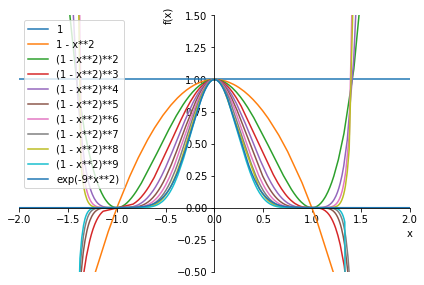

In [8]:
exp = (1 - n*x**2/n)**n
sp.plot(*[exp.subs(n, i) for i in range(10)], sp.exp(-9*x**2), xlim=(-2, 2), ylim=(-0.5, 1.5), legend=True);

As expected, our original function, an inverted parabola, converges to a Gaussian bell curve between $-1$ and $1$ once we take it to a high power. Again, this is in our _unstretched_ coordinate system, and we expect this peak to become narrower and narrower, while looking more and more like a Gaussian bell curve, as $n$ grows.

We are actually not limited to $1-x^2$, because the same holds for this variant:

$$
\lim_{n \rightarrow \infty} (1 - \frac{n|x|^\alpha}{n})^n  \qquad(9)
$$

Our zoomed coordinate system is now $n^{1/\alpha}x$, and in this coordinate system, equation (9) converges to $e^y=e^{-n|x|^\alpha}$. Here is an overview of these exponentials for different values of $\alpha$:

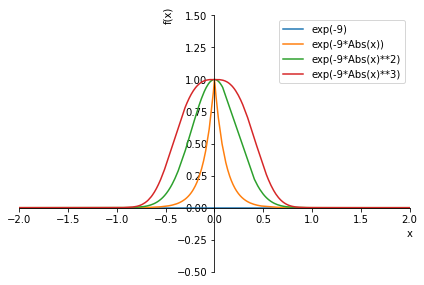

In [10]:
sp.plot(*[sp.exp(-9*abs(x)**alpha).subs(alpha, i) for i in range(0, 4)], xlim=(-2, 2), ylim=(-0.5, 1.5), legend=True);

And here is the explicit convergence of equation (9) for $\alpha=1$:

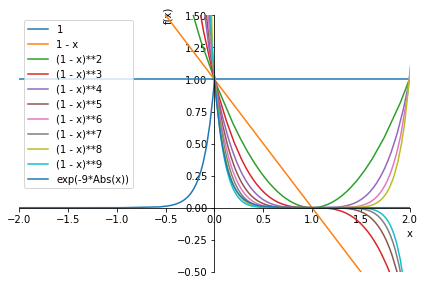

In [12]:
exp = (1 - n*x**alpha/n)**n
sp.plot(*[exp.subs(alpha, 1).subs(n, i) for i in range(10)], sp.exp(-9*abs(x)), xlim=(-2, 2), ylim=(-0.5, 1.5), legend=True);

This looks more or less the same as before with a convergence to the exponential for $x < 1$. What is particular about exponentials with $0 < \alpha < 2$ is that, even though they have a «pointy» maximum at $x=0$ because there is a discontinuity in their first derivative.

We don't expect anything spectacular to happen when $\alpha$ is greater than $2$ except that the Gaussian becomes a bit flatter on top but let's have a look nevertheless to be complete:

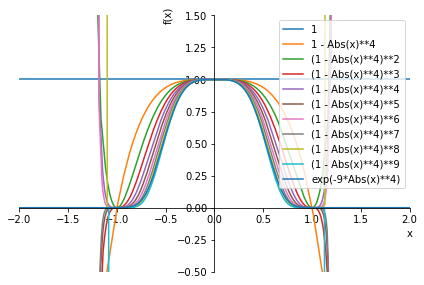

In [13]:
exp = (1 - n*abs(x)**alpha/n)**n
sp.plot(*[exp.subs(alpha, 4).subs(n, i) for i in range(10)], sp.exp(-9*abs(x)**4), xlim=(-2, 2), ylim=(-0.5, 1.5), legend=True);

A final thought is that we seem screwed if we look at _mixed_ polynomials. Consider, for example, the following equation:

$$
\lim_{n \rightarrow \infty} (1 - (x^2 - x))^n  \qquad(10)
$$

There is no _simple_ zoomed coordinate now, because we get:

$$
\lim_{n \rightarrow \infty} (1 - \frac{(n^{1/2}x)^2 - nx}{n})^n  \qquad(11)
$$

However, think about what happens in the coordinate system $y=nx$:

$$
\lim_{n \rightarrow \infty} (1 - \frac{n^{-1/2}y^2 - y}{n})^n  \qquad(12)
$$

In this coordinate system, the quadratic term in $x$ becomes smaller and smaller compared to the linear $x$ term as $n$ grows, and can eventually be neglected. _The smallest power dominates_ in this perspective, and the reason is that the zoomed coordinate systems we introduce zoom in faster for lower powers of $x$, and we thus look have a more localized perspective.

## What this is good for

You may wonder what all of this is good for. To understand where and why the above convergence can occurs, think about the fact that _locally_ most (well-behaved) functions can be approximated as low power polynomials, such as $1-cx^2$ around a maximum where the first derivative is $0$, or $1+cx$ where it is not. This local description corresponds exactly to the terms we have explored above. This has the dramatic implication that, _if I take a function to the power of $n$, it will locally look like a variant of an exponential as $n$ grows_.

For example, take the function $|\cos{x}|$, which has a maxima at multiples of $\pi$. The following plot shows what happens if I take this function to the nth power:

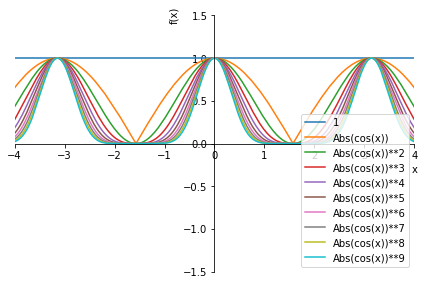

In [15]:
expr = abs(sp.cos(x))**n
sp.plot(*[expr.subs(n,i) for i in range(10)], xlim=(-4, 4), ylim=(-1.5, 1.5), legend=True);

Can you see how the maxima converge to Gaussian bell curves? Take this polynomial for another example, with a local maximum close to $1$:

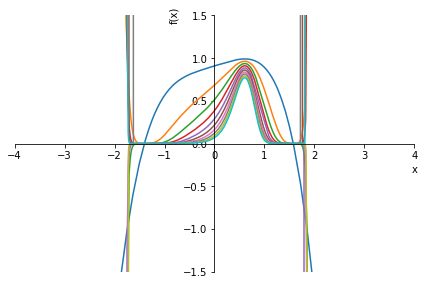

In [16]:
expr = ((5 - x**4 + x - 0.1*x**3)/5.5)**n
expr.subs(x, sp.sqrt(n)*x)
sp.plot(*[expr.subs(n,i) for i in range(1, 30, 3)], xlim=(-4, 4), ylim=(-1.5, 1.5));

Again, convergence of this local maximum to a Gaussian is clearly visible. Furthermore, in the multiplication process, _the global maxima will dominate all other ones_. This means that _any_ bounded function with a single (well-behaved) maximum will converge _globally_ to a Gaussian.

In fact, since this convergence to an exponential is by no means limited to $1-x^2$-like terms, we could make the same argument for any point of the function. This more advanced idea goes like this: when taking a function to the power of $n$, it will locally converge to a Gaussian where its first derivative (but not the second) is zero, that is a local maximum, and it will locally converge to a simple exponential where its first derivative is non-zero. I didn't look at points where 1st and 2nd derivatives are zero, but I am sure there are similar analogies. Thus, as conclusion, taking a «smooth» function to a large power «exponentializes» it so that it will look like min-Gaussian's around it's maxima and exponentials connecting them.

# Part 2

## Introduction

Whoever has computed sums of random variables knows that they have a tendency to become normal - under certain conditions. This behaviour is summed up in the central limit theorem and is one primary reason for the exceptional position that the normal distribution takes. It is an _attractor_ for distributions.

In the last post in this series, we talked about how functions locally converge to exponentials under repeated _multiplication_ with themselves, in particular how function maxima converge to Gaussian bell curves the same shape as a normal distribution.

We will now connect this local convergence to exponentials with the convergence of distributions to normal. This connection happens in several steps:

- first the sum of random variables is the convolution of their distributions;
- second, in Fourier space, convolution becomes multiplication and distribution converge to normal as described previously;
- third, the inverse Fourier transform (the original distribution) of a normal is also normal.

This is straight forward but there are a few subtleties to this to really understand what is going on. And once we do, it is quite natural to also understand when the central limit theorem _doesn't_ apply and what other functions than normal certain distributions, in particular those with a long power-law tail, can converge to. This latter behavior is described by the so-called _generalized_ central limit theorem.

## Illustrating the central limit theorem

Since we are dealing quite a lot with Fourier transforms in this post, we will use the same coordinate system throughout the post to compute them on different example functions. We will also use the scipy stats module and matplotlib's pyplot (with seaborn theme) for plotting.

In [22]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

dt = 0.1
nyq = 2/dt
x = np.arange(-1000, 1000, dt)
f = np.fft.fftshift(np.fft.fftfreq(n=len(x))) * nyq

To get a better understanding of the central limit theorem, let's have a look at a lognormal, a uniform and an exponential distribution under repeated convolution:

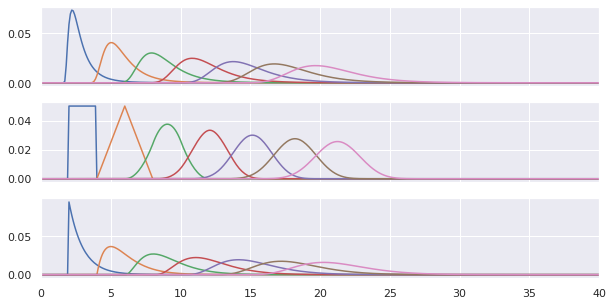

In [23]:
dists = [stats.lognorm.pdf(x, loc=np.log(5), s=np.log(2)),
         stats.uniform.pdf(x, loc=2, scale=2),
         stats.expon.pdf(x, loc=2, scale=1)]

ndists = len(dists)
fig, axes = plt.subplots(ndists, 1, figsize=(10, 5), sharex=True)
for ax, dist in zip(axes, dists):
    acc = [1.0]
    scanned = [acc := np.convolve(acc, x, "same") for x in [dist]*7]
    for scan in scanned:
        ax.plot(x, scan/scan.sum())
ax.set(xlim=(0, 40));

You will notice that the sharp edges and asymmetries of any of these functions fade away as the function is convoluted with itself. What remains is some distribution that resembles a Gaussian/Normal distribution.

The convolution of functions becomes much easier to grasp when using characteristic functions, the Fourier transform of a distribution. It can be computed numerically with the Fast Fourier Transformation (FFT). Here is the characteristic function of a simple uniform distribution:

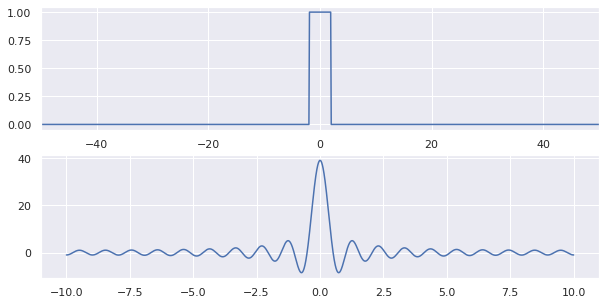

In [24]:
y = np.zeros_like(x); y[:20] = 1; y[-19:] =1
Y = np.fft.fftshift(np.fft.fft(y))

fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 5))
ax1.plot(x, np.fft.fftshift(y))
ax1.set(xlim=(-50, 50))
ax2.plot(f, np.real(Y));

As a quick reminder: length scales are essentially inverted in the Fourier transform. The large scale behaviour of the distribution is determined by frequencies close to zero, and small scale fluctuations by frequencies with high absolute value. For example, the little wiggles you see mostly determine the sharp edges of the uniform distribution whereas the central peak determines where its principal is.
The imaginary part of the characteristic function is zero because the distribution is symmetric, which is why we don't plot it (yet).

Let's have a look what happens to the distribution and the characteristic function if we start convolving the distribution with itself.In the Fourier domain this simply means multiplying the spectrum with itself, and since it is a real number this is quite easy.

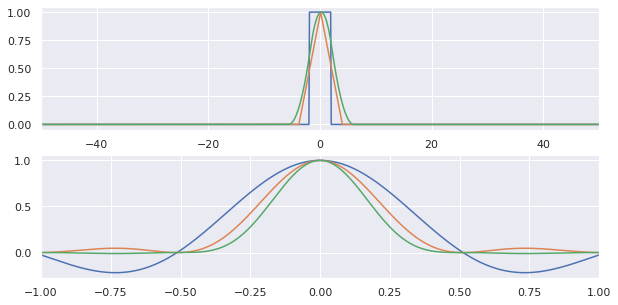

In [25]:
nconvolutions = 3
acc = [1.0]; scanned1 = [acc := np.convolve(acc, np.fft.fftshift(e), "same") for e in [y]*nconvolutions]
ACC = np.ones_like(Y); scanned2 = [ACC := ACC * e for e in [Y]*nconvolutions]

fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 5))
for s, S in list(zip(scanned1, scanned2)):
    snorm, Snorm = s/s.max(), S / np.abs(S).max()
    ax1.plot(x, snorm)
    ax2.plot(f, np.real(Snorm))
ax1.set(xlim=(-50, 50))
ax2.set(xlim=(-1, 1));

In only three iterations the distribution and its characteristic function closely resemble a Gaussian.
How did this happen magically? Well, we know from our last post why the characteristic function converges to a Gaussian - and the original distribution needs to converge to a Gaussian as well since a Gaussian is its own Fourier transform.

## Properties of characteristic functions

One property that _all_ characteristic functions have is a central peak at frequency $0$ with value $1$. This is because the value of the characteristic function at zero frequency, corresponding to a flat cosine with infinite wavelength, is simply the norm of the distribution. All other absolute values of characteristic function are smaller than one. What happens is that, when multiplying the spectrum with itself over and over again, smaller values decay faster than larger ones, and after a few iterations, only the central peak survives that is close to 1. And this peak starts to resemble a Gaussian because it locally looks like $1-x^2$ and then gets exponentialized.


- large scale behaviour is determined by peak
- peak is always maximum and at 1 since this is the largest scale and the norm of the distribution
- peak is typically smooth and can be approximated with 1-x2

What functions leed to non-smooth distributions?

## Generalized Central Limit Theorem and Power Laws

What if we consider distributions with _infinite_ variance or mean.
Such distributions sound crazy but actually occur quite often.
Two central thoughts are important to understand the behaviour of the generalized central limit theorem: $x^\alpha \propto \omega^{-(\alpha + 1)}$  says that a power law in the time domain corresponds to a power law with negative and increased by one exponent in the Fourier domain.

For example, a straight line (exponent $\alpha=1$) in time domain corresponds to a square decay (exponent $\beta=-2$) in Fourier domain,
and a $1/x$ decay (exponent $\alpha=-1$) corresponds to a constant spectrum in Fourier domain.
The point of equilibrium is reached at $\alpha=0.5$ where $\beta=0.5$ as well - a special place which corresponds to pink noise or even power per log unit such as decibel or octave.

In addition to this, it is important to remember that length scales in Fourier space are inverted: _low_ frequency determine the large scale changes and _high_ frequencies the short scale behaviour.
To understand, for example, the large scale asymptotic behaviour of a function from its Fourier transform, we need to look at its behavior around 0 - something we will do extensively in this article.

Consider for example the following function that falls of with exponent $\alpha=-2$, corresponding to $\beta=1$ in Fourier domain.
Careful, you might expect the Fourier spectrum to _rise_ with frequency, but it could equally fall as in $-f$ and in addition it could be shifted by a constant $c - mf$. All the above equation says is that the square dropoff in time at large scale should correspond to a _linear_ bahviour of the spectrum at _low_ frequencies.

Equipped with these warning let's have a look:

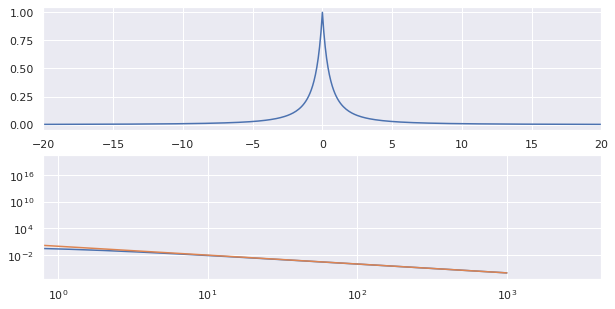

In [26]:
y = 1./(1 + np.abs(x)) ** 2

fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 5))
ax1.plot(x, y)
ax1.set(xlim=(-20, 20))
ax2.plot(x[x>0], y[x>0])
ax2.plot(x[x>0], x[x>0]**-2)
ax2.set(xscale="log", yscale="log", xlim=(0.8, None));